In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import files

uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [5]:
import zipfile
import os

zip_path = "archive (2).zip"   # Name of your uploaded ZIP file

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Files extracted successfully!")
print(os.listdir("dataset"))

Files extracted successfully!
['True.csv', 'Fake.csv']


In [6]:
import pandas as pd

fake = pd.read_csv("dataset/Fake.csv")
real = pd.read_csv("dataset/True.csv")

In [7]:
fake = pd.read_csv("dataset/Fake.csv")
real = pd.read_csv("dataset/True.csv")

In [8]:
print(fake.head())

print(real.head())

print(fake.shape)

print(real.shape)

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [9]:
fake["label"] = 1
real["label"] = 0

Merge the Datasets

In [10]:
import pandas as pd

df = pd.concat([fake, real], ignore_index=True)

df = df[["text", "label"]]

df.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,1
1,House Intelligence Committee Chairman Devin Nu...,1
2,"On Friday, it was revealed that former Milwauk...",1
3,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis used his annual Christmas Day mes...,1


In [11]:
print(df.shape)

df["label"].value_counts()

(44898, 2)


,count
label,
1,23481
0,21417


In [12]:
os.listdir("dataset")

['True.csv', 'Fake.csv']

# Split the Dataset

In [13]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 35918
Testing samples: 8980


# Tokenize the Text

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 10000

tokenizer = Tokenizer(num_words=MAX_WORDS)

tokenizer.fit_on_texts(X_train)

# Convert Text into Sequences

In [15]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 300

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(X_train_pad.shape)
print(X_test_pad.shape)

(35918, 300)
(8980, 300)


# Build the CNN Model

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile the Model

In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [19]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9623 - loss: 0.0924 - val_accuracy: 0.9989 - val_loss: 0.0053
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9977 - loss: 0.0073 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.9994 - val_loss: 0.0040
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9994 - loss: 0.0018 - val_accuracy: 0.9987 - val_loss: 0.0059
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9989 - val_loss: 0.0067


In [20]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9992 - loss: 0.0060
Test Loss: 0.005961560644209385
Test Accuracy: 0.9992204904556274


In [21]:
y_prob = model.predict(X_test_pad)

y_pred = (y_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully.")

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated successfully.


In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Real News", "Fake News"]
))

              precision    recall  f1-score   support

   Real News       1.00      1.00      1.00      4284
   Fake News       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



# Confusion Matrix

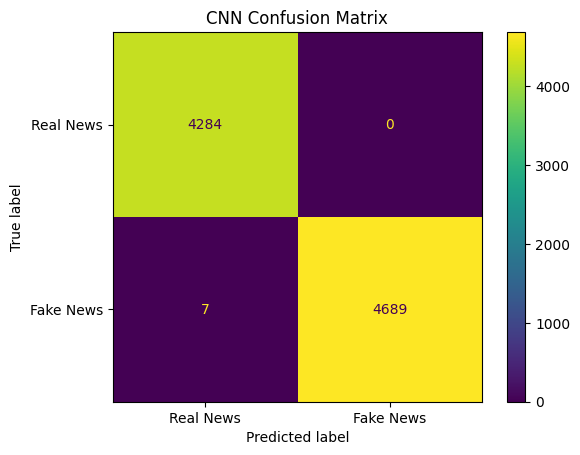

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real News", "Fake News"]
)

disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

# Plot Training Accuracy

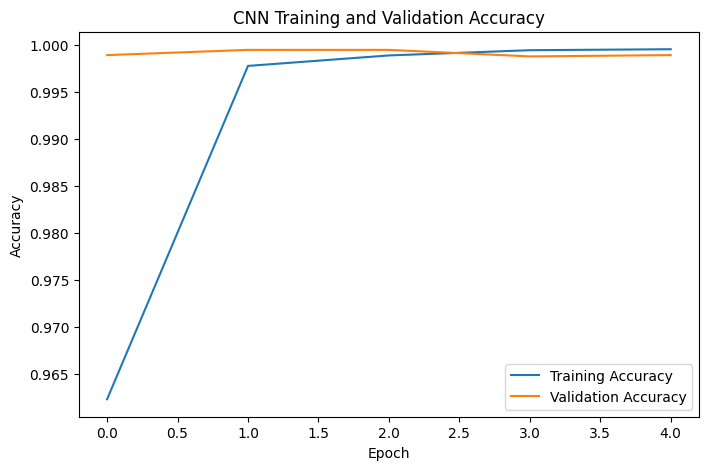

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

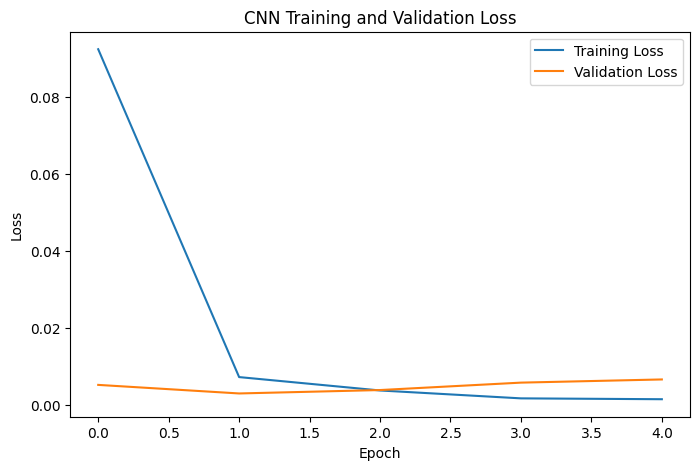

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [26]:
model.save("cnn_model.keras")

print("CNN model saved successfully.")

CNN model saved successfully.


In [27]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


In [28]:
import os

print(os.listdir())

['.config', 'archive (2).zip', 'cnn_model.keras', 'tokenizer.pkl', 'dataset', 'sample_data']


In [29]:
from google.colab import files

files.download("cnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>